<a href="https://colab.research.google.com/github/codeBMB/July26_BCCE/blob/main/example_colabs/Acid_Base_Titration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img align="right" src="https://github.com/codeBMB/April26_Rutgers-RCSB/raw/main/images/PyBMB_logo.png" width="150" height="150" />

# Project: CodeBMB: Computational Literacy for Biochemistry and Molecular Biology Education
## Notebook: Acid-Base Titration Analysis

**Purpose**
This notebook analyzes your acid-base titration data to determine:
1. **Part 1:** The equivalent mass of an unknown acid (from a single-endpoint titration)
2. **Part 2:** Explore the Henderson-Hasselbalch equation

**Input Data:**
Data from an acid-base titration. You will manually enter the values

**Libraries**
* pandas
* numpy
* matplotlib
* scipy

**Status with Date:**
Work in Progress (7/9/26)

**License**

<img src="https://github.com/codeBMB/April26_Rutgers-RCSB/raw/main/images/by-nc-sa.png" width="100" alttext="[CC BY-NC-SA](https://creativecommons.org/licenses/by-nc-sa/4.0/)"/>
 This license enables reusers to distribute, remix, adapt, and build upon the material in any medium or format for noncommercial purposes only, and only so long as attribution is given to the creator. If you remix, adapt, or build upon the material, you must license the modified material under identical terms. CC BY-NC-SA includes the following elements:
 BY: credit must be given to the creator.
 NC: Only noncommercial uses of the work are permitted.
 SA: Adaptations must be shared under the same terms.

---
**Authorship:** Chris Berndsen

**Acknowledgements:** This workshop is supported by NSF IUSE 2518733

**Contact Info:** Please contact us at codingforBMB@gmail.com

---
## SECTION 0: Import Libraries

In [ ]:
# Import all the tools we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import curve_fit

# Make our plots a nice readable size
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['font.size'] = 11

---
## PART 1: EQUIVALENT MASS OF AN UNKNOWN ACID


### Step 1A: Standardizing NaOH with HCl

In [ ]:
# ===== ENTER YOUR OWN DATA BELOW =====
# Replace every number with your own lab data. Keep one value per trial.
# The example values below are placeholders only.

# Molarity of the standardized HCl solution (from the reagent bottle label)
HCl_molarity = ______  # mol/L

# Buret readings for the HCl delivered into the flask (mL), one entry per trial
# Add or delete blanks as needed
HCl_initial = [____, ____, ____]
HCl_final   = [____, _____, _____]

# Buret readings for the NaOH used to titrate that HCl (mL), one entry per trial
NaOH_initial_std = [____, _____, ____]
NaOH_final_std   = [____, _____, ____]


print("Standardization data entered")

NameError: name '______' is not defined

In [ ]:
# We convert our lists into numpy arrays first so we can do math on all trials at once
# Each list from above should be surrounded by processed using np.array(list_name)
# File in the blanks below with the appropriate list_name, remember to match case and spacing


# Calculate the volume of HCl actually delivered in each trial (final - initial)
HCl_volume_mL = np.array(______) - np.array(______)

# Calculate moles of HCl used in each trial
# moles = Molarity (mol/L) x Volume (L)      -->  divide mL by 1000 to get L
moles_HCl = ________ * (______/1000)

# Calculate the volume of NaOH used to reach the endpoint in each trial
NaOH_volume_std_mL = np.array(_____) - np.array(______)

print("HCl volume used (mL):", HCl_volume_mL)
print("Moles of HCl:", moles_HCl)
print("NaOH volume used (mL):", NaOH_volume_std_mL)

HCl volume used (mL): [19.96 20.01 19.96]
Moles of HCl: [0.001996 0.002001 0.001996]
NaOH volume used (mL): [19.8  19.79 19.82]


In [ ]:
# Notice above the numbers have a lot of decimal places, we can type .round() and put a number
# inside the parenthesis to make the number have the correct number of significant figures.
# Adjust the number of sig figs in the commands below

print("HCl volume used (mL):", HCl_volume_mL.round(_))
print("Moles of HCl:", moles_HCl._____(_))
print("NaOH volume used (mL):", NaOH_volume_std_mL.____(_))

In [ ]:
# At the endpoint, moles of NaOH added = moles of HCl neutralized
moles_NaOH = moles_HCl

# Molarity of NaOH = moles / NaOH volume (in L)
NaOH_molarity_trials = _______ / (_______ / ______)

print("NaOH molarity for each trial:", NaOH_molarity_trials.______(_)) # remember sig figs!

# Calculate the average and standard deviation across trials
NaOH_molarity_avg = np.mean(NaOH_molarity_trials)
NaOH_molarity_std = np.std(NaOH_molarity_trials)

# adjust the number in front of f to change sig figs
print("Average NaOH molarity =", __________._____(_), "M")
print("Standard Deviation of the molarity", NaOH_molarity_std._____(_), "M")

SyntaxError: unexpected character after line continuation character (3102490199.py, line 14)

### Propagating Uncertainty from Your Glassware

So far, the ± on your equivalent mass comes from the *scatter between trials* (the standard deviation). But there's a second source of uncertainty: the *precision of your instruments themselves*. Every buret and balance has a built-in reading uncertainty, usually printed on the equipment or given by your instructor (a common rule of thumb is ± half of the smallest graduation).

Look up (or ask your instructor for) the reading uncertainty of the buret and analytical balance you used, and enter them below.

In [ ]:
# ===== ENTER YOUR GLASSWARE UNCERTAINTIES BELOW =====
buret_uncertainty_mL = ____     # e.g. 0.02 mL
balance_uncertainty_g = _____    # e.g. 0.0001 g

✓ Glassware uncertainties entered


In [ ]:
# Each buret VOLUME is a subtraction of two readings (final - initial), each carrying
# the same reading uncertainty. For subtraction, absolute uncertainties combine in quadrature:
sigma_volume = np.sqrt(buret_uncertainty_mL**2 + buret_uncertainty_mL**2)

print("Uncertainty in each NaOH volume reading:", _________ ,"mL")

Uncertainty in each NaOH volume reading: ±0.071 mL


---
## PART 2: IDENTIFYING AN UNKNOWN WEAK ACID FROM ITS TITRATION CURVE

**Goal:** Plot your pH vs. volume data, find the equivalence point and half-equivalence point, and use them to determine the molar mass and pKa of your unknown weak acid.

In [ ]:
# ===== ENTER YOUR OWN DATA BELOW =====
# Enter the volume of NaOH added (mL) and the corresponding pH reading, in the SAME order
# you collected them. Both lists must have the same number of entries.

volume_mL = [0.0, ___, ____] # add or delete blanks as needed

pH = [___,____,____] # add or delete blanks as needed

# Combine the two lists into a single DataFrame (a data table)
titration_df = pd.DataFrame({"volume_mL": volume_mL, "pH": pH})

titration_df.head()

,volume_mL,pH
0,0.0,2.58
1,4.0,3.13
2,8.0,3.52
3,12.0,3.82
4,15.0,4.03


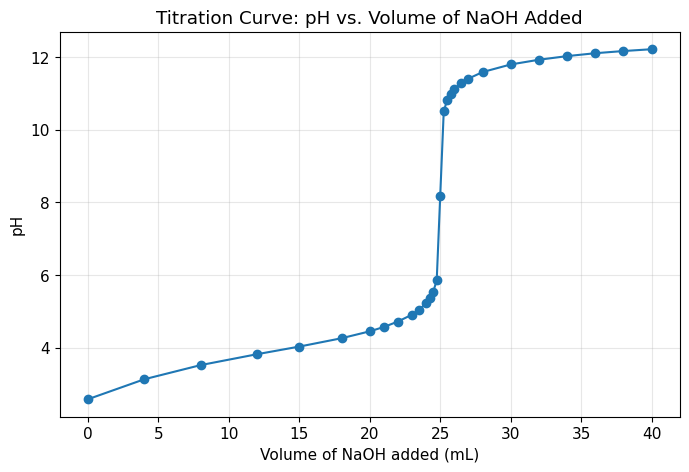

In [ ]:
# Plot pH (y-axis) vs. volume of NaOH added (x-axis)
fig, ax = plt.subplots()

ax.scatter(titration_df["volume_mL"], titration_df["pH"], marker='o')
ax.set_xlabel("Volume of NaOH added (mL)")
ax.set_ylabel("pH")
ax.set_title("Titration Curve: pH vs. Volume of NaOH Added")
ax.grid(True, alpha=0.3)

plt.show()

### Estimate the Equivalence Point by Eye

Look at the graph above. The equivalence point is in the middle of the region where the pH rises steeply. Estimate that volume by eye before letting Python calculate it for you.

In [ ]:
# Enter your own visual estimate of the equivalence point volume (mL), based on the graph above
my_equivalence_point_guess = _____

print("Your estimated equivalence point:", my_equivalence_point_guess,"mL")

Your estimated equivalence point: 24 mL


### Now Let Python Calculate It — Fitting a Curve

Instead of drawing tangent lines by hand, we can fit a smooth mathematical curve to your *entire* data set, then find the point where that curve is steepest (its inflection point). A sigmoid (S-shaped) curve is a good match for the shape of a titration curve:

$$pH(V) = bottom + \dfrac{top - bottom}{1 + 10^{(V_{50}-V)/width}}$$

Here, $V_{50}$ is the volume at the curve's midpoint (its inflection point) — exactly the equivalence point we're looking for.

In [ ]:
# Define the sigmoid function. bottom/top are the pH plateaus, V50 is the inflection point
# (our equivalence point), and width controls how sharply the curve rises.
def sigmoid(V, bottom, top, V50, width):
    return bottom + (top - bottom) / (1 + 10**((V50 - V) / width))

In [ ]:
# curve_fit needs a starting guess for each parameter: [bottom, top, V50_guess, width_guess]
# Use the min/max pH from your data, and your own equivalence point guess as the V50 starting point
initial_guess = [titration_df["pH"].min(), titration_df["pH"].max(), 17, 1]

params, covariance = curve_fit(sigmoid, titration_df["volume_mL"], titration_df["pH"], p0=initial_guess)

bottom_fit, top_fit, V50_fit, width_fit = params

print("Fitted equivalence point (V50) =", V50_fit._____(_), "mL")

Fitted equivalence point (V50) = 24.95 mL


In [ ]:
# Generate a smooth curve from the fitted parameters so we can plot it
volume_smooth = np.linspace(titration_df["volume_mL"].min(), titration_df["volume_mL"].max(), 300)
pH_smooth = sigmoid(volume_smooth, *params)

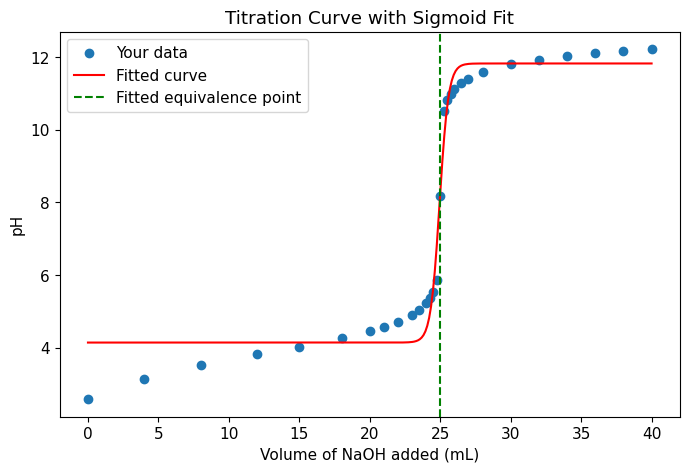

Your guess:               24 mL
Curve-fit equivalence pt: 24.95 mL


In [ ]:
# plot the data
fig, ax = plt.subplots()
ax.scatter(titration_df["volume_mL"], titration_df["pH"], label="Your data")
ax.plot(volume_smooth, pH_smooth, color='red', label="Fitted curve")
ax.axvline(V50_fit, color='green', linestyle='--', label="Fitted equivalence point")
ax.set_xlabel("Volume of NaOH added (mL)")
ax.set_ylabel("pH")
ax.set_title("Titration Curve with Sigmoid Fit")
ax.legend()

plt.show()

print(f"Your guess:               {my_equivalence_point_guess} mL")
print(f"Curve-fit equivalence pt: {V50_fit:.2f} mL")

In [ ]:
# We'll use the curve-fit value going forward, since it uses ALL of your data at once
equivalence_volume = V50_fit

Notice that the read line fit is not that great. It likely produces an accurate equivalence point but it looks messy. Below we will do a more accurate fit to show that the rough fit (while decidedly ugly), is good enough for this application.

We need to to enter some data before hand to help with the fitting

In [ ]:
# Volume of solution the weak acid was originally dissolved in (mL)
initial_volume_mL = 50.0. # Your instructor might give you this number



In [ ]:


# Convert to liters for the equations below
V0 = initial_volume_mL / 1000
Cb = NaOH_molarity_avg  # concentration of the NaOH titrant

# ---- The mechanistic model: volume needed to reach a given pH ----
def volume_model(pH_array, Ka, n0):
    H = 10**(-pH_array)
    OH = 1e-14 / H
    alpha = Ka / (Ka + H)
    return (n0 * alpha + V0 * (OH - H)) / (Cb + H - OH) * 1000  # returns mL

# Initial guesses: use the pKa/moles you already estimated
Ka_guess = 10**(-1)
n0_guess = NaOH_molarity_avg * (equivalence_volume / 1000)

# Fit "sideways": pH is the input, volume is the output
mech_params, mech_covariance = curve_fit(
    volume_model,
    titration_df["pH"],
    titration_df["volume_mL"],
    p0=[Ka_guess, n0_guess],
    bounds=([1e-10, 1e-6], [1, 1])
)

Ka_fit, n0_fit = mech_params
pKa_fit = -np.log10(Ka_fit)
equivalence_volume_mech = n0_fit / Cb * 1000

print(f"Mechanistic fit:  pKa = {pKa_fit:.3f}   Ka = {Ka_fit:.3e}")
print(f"Mechanistic fit:  equivalence point = {equivalence_volume_mech:.2f} mL")

# ---- Overlay both models on the same plot ----
pH_smooth_mech = np.linspace(titration_df["pH"].min(), titration_df["pH"].max(), 300)
volume_smooth_mech = volume_model(pH_smooth_mech, Ka_fit, n0_fit)

fig, ax = plt.subplots()
ax.scatter(titration_df["volume_mL"], titration_df["pH"], label="Your data", zorder=3)
ax.plot(volume_smooth, pH_smooth, color='red', label="Sigmoid fit")
ax.plot(volume_smooth_mech, pH_smooth_mech, color='blue', linestyle='--', label="Mechanistic fit")
ax.axvline(V50_fit, color='red', linestyle=':', alpha=0.6)
ax.axvline(equivalence_volume_mech, color='blue', linestyle=':', alpha=0.6)
ax.set_xlabel("Volume of NaOH added (mL)")
ax.set_ylabel("pH")
ax.set_title("Sigmoid Fit vs. Mechanistic Titration Model")
ax.legend()

plt.show()

Mechanistic fit:  pKa = 3.844   Ka = 1.432e-04
Mechanistic fit:  equivalence point = 25.02 mL


It is likely that the mechanistic fit provides a similar value to the direct fit. If they are way off and the plot looks weird, check your input volume.

### Half-Equivalence Point and pKa

At the half-equivalence point, half of the weak acid has been converted to its conjugate base, so [HA] = [A\u207b]. At this point, pH = pKa (see Henderson-Hasselbalch below).

In [ ]:
# The half-equivalence volume is half of the equivalence volume
half_equivalence_volume = __________ / _____

# Find which row in our data has a volume closest to the half-equivalence volume
closest_index = (titration_df["volume_mL"] - half_equivalence_volume).abs().idxmin()

# The pH at that row is our pKa estimate
pKa = titration_df["pH"][closest_index]

print(f"Half-equivalence volume = {half_equivalence_volume:.2f} mL")
print(f"pKa of unknown acid = {pKa:.2f}")

# Ka = 10^(-pKa)
Ka = 10**(-___)
print(f"Ka = {Ka:.2e}")

Half-equivalence volume = 8.87 mL
pKa of unknown acid = 3.52
Ka = 3.02e-04


---
## THE HENDERSON-HASSELBALCH EQUATION

The Henderson-Hasselbalch equation relates the pH of a buffer to its pKa and the ratio of conjugate base to weak acid:

$$pH = pKa + \log_{10}\left(\frac{[A^-]}{[HA]}\right)$$

Notice that when [A\u207b] = [HA] (a 1:1 ratio), the log term is zero, so pH = pKa. That's exactly the half-equivalence point you just found!

**Goal:** Explore how pH changes as the ratio of [A-] to [HA] changes.

In [ ]:
# Define a function that calculates pH from pKa and the ratio [A-]/[HA]
def calc_pH(pKa_value, ratio):
    # put pka_value and ratio in the proper place of the equation
    return ______ + np.log10(_____)

# Quick check: a 1:1 ratio should give pH = pKa, using pKa from above
print("Check: pH at ratio = 1 is", calc_pH(pKa, 1), " (should equal pKa =", pKa, ")")

Check: pH at ratio = 1 is 3.52  (should equal pKa = 3.52 )


### Buffer "What If" Exploration

Use your `calc_pH` function to answer the questions below by filling in the ratio each time.

In [ ]:
# What is the pH when there is 3 times MORE conjugate base (A-) than acid (HA)?
ratio_more_base = 3
pH_more_base = calc_pH(pKa, ratio_more_base)
print(f"pH when [A-]/[HA] = {ratio_more_base}: {pH_more_base:.2f}")

# What is the pH when there is 3 times MORE acid (HA) than conjugate base (A-)?
ratio_more_acid = 1/3
pH_more_acid = calc_pH(pKa, ratio_more_acid)
print(f"pH when [A-]/[HA] = {ratio_more_acid}: {pH_more_acid:.2f}")

pH when [A-]/[HA] = 3: 4.00
pH when [A-]/[HA] = 0.3333333333333333: 3.04
